# 特征值与二次型

学习目标：从面积变化和不变方向理解矩阵，用特征分解判断二维二次型的符号与等高线形状，并检查结论所需的矩阵条件。

前置知识：线性变换、矩阵乘法与转置、线性方程组、基、内积。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；使用实数小矩阵，复数特征值单独说明。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 行列式记录面积怎样变化

把单位正方形的两条边变成 $(2,0)^T$ 和 $(1,3)^T$，新图形是底为 2、高为 3 的平行四边形，面积为 6。对应的线性变换矩阵是

$$A=\begin{pmatrix}2&1\\0&3\end{pmatrix}.$$

一般地，实数 $a,b,c,d$ 构成的二阶方阵有行列式（determinant）

$$\det\begin{pmatrix}a&b\\c&d\end{pmatrix}=ad-bc.$$

行列式是一个数。它的绝对值给出面积缩放倍数；负号表示有向基的取向发生反转，不表示面积为负。行列式为零时，二维图形被压到直线或点，失去面积。

下面把数学列向量存成形状为 (2,) 的 NumPy 一维数组；多个顶点按列排成形状为 (2, 5) 的数组。矩阵乘法使用 @，不是逐元素乘法 *。图中坐标均无物理单位。

手算行列式： 6.0
NumPy 行列式： 6.0


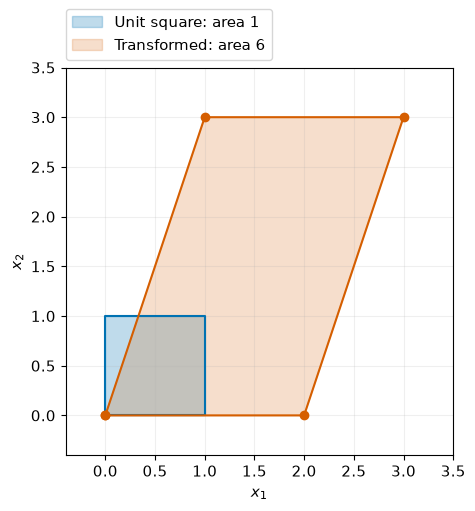

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11}
)

# 单位正方形按列保存顶点；重复首点闭合边界，矩阵一次变换全部顶点。
a = np.array([[2.0, 1.0], [0.0, 3.0]])
square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
mapped = a @ square
det_by_hand = a[0, 0] * a[1, 1] - a[0, 1] * a[1, 0]
print("手算行列式：", det_by_hand)  # 预期为 6。
print("NumPy 行列式：", np.linalg.det(a))  # 浮点结果接近 6。

# 填充变换前后的区域，并保持等比例坐标，以面积观察行列式的作用。
fig, ax = plt.subplots(figsize=(5.5, 5.0), layout="constrained")
ax.fill(square[0], square[1], color="#0072B2", alpha=0.25, label="Unit square: area 1")
ax.plot(square[0], square[1], color="#0072B2")
ax.fill(mapped[0], mapped[1], color="#D55E00", alpha=0.2, label="Transformed: area 6")
ax.plot(mapped[0], mapped[1], "o-", color="#D55E00")
ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$", xlim=(-0.4, 3.5), ylim=(-0.4, 3.5))
ax.set_aspect("equal")
ax.grid(alpha=0.2)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), borderaxespad=0)
# 预期图中单位正方形变成面积为 6 的平行四边形，原点保持不动。
plt.show()

对于 $n\times n$ 实方阵，$n$ 是正整数，$|\det A|$ 对应 $n$ 维体积的缩放倍数；三维就是通常的体积。$\det A=0$ 等价于列向量线性相关，也等价于矩阵不可逆。

比较反射和压扁可以区分“符号变了”与“维度丢失了”。下面的反射保留面积，压扁把所有点送到横轴。

In [2]:
reflection = np.array([[-1.0, 0.0], [0.0, 1.0]])
flattening = np.array([[1.0, 1.0], [0.0, 0.0]])

for name, matrix in [("反射", reflection), ("压扁", flattening)]:
    print(name, "行列式：", np.linalg.det(matrix))  # 分别为 -1 和 0。
    print("变换后的顶点：\n", matrix @ square)  # 反射后的横坐标为 0、-1、-1、0、0；压扁后的纵坐标全为 0。

反射 行列式： -1.0
变换后的顶点：
 [[ 0. -1. -1.  0.  0.]
 [ 0.  0.  1.  1.  0.]]
压扁 行列式： 0.0
变换后的顶点：
 [[0. 1. 2. 1. 0.]
 [0. 0. 0. 0. 0.]]


## 2 特征向量找到不改变直线方向的向量

考虑 $A=\begin{pmatrix}2&1\\1&2\end{pmatrix}$。它把 $(1,1)^T$ 变为 $(3,3)^T$，把 $(1,-1)^T$ 保持不变。两条过原点的直线在变换后仍是原来的直线。

对 $n\times n$ 方阵 $A$，如果非零列向量 $v\in\mathbb R^n$ 和实数 $\lambda$ 满足

$$Av=\lambda v,$$

就称 $v$ 为特征向量（eigenvector），$\lambda$ 为对应的特征值（eigenvalue）。这里先讨论实特征对；并非每个实矩阵都有实特征向量。

$\lambda>0$ 表示沿该方向伸缩，$\lambda<0$ 还会反向，$\lambda=0$ 则把向量送到零向量。特征值可以是零，特征向量不能是零，否则任意 $\lambda$ 都满足等式。

In [3]:
a = np.array([[2.0, 1.0], [1.0, 2.0]])
v1 = np.array([1.0, 1.0])
v2 = np.array([1.0, -1.0])

print("A v1：", a @ v1, "；3 v1：", 3 * v1)  # 预期为 [3. 3.] ；3 v1： [3. 3.]。
print("A v2：", a @ v2, "；1 v2：", v2)  # 预期为 [ 1. -1.] ；1 v2： [ 1. -1.]。
print("两个特征关系的残差：", a @ v1 - 3 * v1, a @ v2 - v2)  # 预期为 [0. 0.] [0. 0.]。
# 残差均为零；同一特征向量乘任意非零数，仍是对应特征向量。
print("换用 -2 v1 的残差：", a @ (-2 * v1) - 3 * (-2 * v1))  # 预期为 [0. 0.]。

A v1： [3. 3.] ；3 v1： [3. 3.]
A v2： [ 1. -1.] ；1 v2： [ 1. -1.]
两个特征关系的残差： [0. 0.] [0. 0.]
换用 -2 v1 的残差： [0. 0.]


### 2.1 从特征方程得到特征对

把等式改写成 $(A-\lambda I)v=0$，其中 $I$ 是 $n\times n$ 单位矩阵。存在非零解的条件是

$$\det(A-\lambda I)=0.$$

左边称为特征多项式。本例可直接展开：

$$\det(A-\lambda I)=(2-\lambda)^2-1=(\lambda-1)(\lambda-3).$$

因此特征值为 1 和 3。代入 $\lambda=1$ 得到 $v_1+v_2=0$，代入 $\lambda=3$ 得到 $v_1-v_2=0$；此处 $v_1,v_2$ 表示向量 $v$ 的两个分量。解空间含有零向量，但只有非零解是特征向量。

np.linalg.eig 用于一般方阵，返回特征值数组和按列存放的特征向量。同一列必须与同一位置的特征值配对，输出顺序不保证递增；向量的符号也不必与手算相同。

In [4]:
values, vectors = np.linalg.eig(a)
# 输出若带有 +0.j，表示虚部为零，数值仍对应手算的实特征值。
print("特征值：", values)  # 预期为 [3.+0.j 1.+0.j]。
print("特征向量按列排列：\n", vectors)  # 预期约为 [[ 0.707107+0.j -0.707107+0.j] [ 0.707107+0.j 0.707107+0.j]]。

for index, value in enumerate(values):
    vector = vectors[:, index]
    residual = a @ vector - value * vector
    print(f"第 {index + 1} 对的残差：", residual)  # 预期两个特征对的残差接近零向量；本次均显示为 [0, 0]（复数数组）。
# 本例数值尺度约为 1，使用 1e-12 检查接近零的残差；这不是精确证明。
# 预期为 True。
print(
    "特征关系近似成立：", np.allclose(a @ vectors, vectors * values, atol=1e-12, rtol=0)
)

特征值： [3.+0.j 1.+0.j]
特征向量按列排列：
 [[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]
第 1 对的残差： [0.+0.j 0.+0.j]
第 2 对的残差： [0.+0.j 0.+0.j]
特征关系近似成立： True


## 3 对角化需要足够多的独立特征向量

把 $n$ 个线性无关的特征向量依次放进矩阵 $P$ 的列，把对应特征值放进对角矩阵 $D$。逐列的特征关系合起来就是

$$AP=PD\quad\Longrightarrow\quad A=PDP^{-1}.$$

这个表示称为对角化（diagonalization）。在由这些特征向量组成的基下，线性变换只做各坐标分量的伸缩。$P$ 必须可逆，列向量和 $D$ 的排列必须对应。

本例取 $P=\begin{pmatrix}1&1\\1&-1\end{pmatrix}$、$D=\operatorname{diag}(3,1)$。重复作用时，中间的 $P^{-1}P$ 相消，得到 $A^k=PD^kP^{-1}$，其中 $k$ 为正整数。这里求逆只用于核对这个小矩阵恒等式。

In [5]:
p = np.array([[1.0, 1.0], [1.0, -1.0]])
d = np.diag([3.0, 1.0])
p_inverse = np.linalg.inv(p)

print("AP - PD：\n", a @ p - p @ d)  # 预期为 [[0. 0.] [0. 0.]]。
print("重构的 A：\n", p @ d @ p_inverse)  # 预期为 [[2. 1.] [1. 2.]]。
print("A 的三次幂：\n", np.linalg.matrix_power(a, 3))  # 预期为 [[14. 13.] [13. 14.]]。
print("用对角矩阵计算：\n", p @ np.linalg.matrix_power(d, 3) @ p_inverse)  # 预期为 [[14. 13.] [13. 14.]]。
# 两种方式都得到 [[14, 13], [13, 14]]。

AP - PD：
 [[0. 0.]
 [0. 0.]]
重构的 A：
 [[2. 1.]
 [1. 2.]]
A 的三次幂：
 [[14. 13.]
 [13. 14.]]
用对角矩阵计算：
 [[14. 13.]
 [13. 14.]]


### 3.1 重复特征值不直接决定能否对角化

实方阵能够在实数范围内对角化，当且仅当能找到 $n$ 个线性无关的实特征向量。$n$ 个互不相同的实特征值足以保证这一点，但不是必要条件。

比较下面两个矩阵：

$$I=\begin{pmatrix}1&0\\0&1\end{pmatrix},\qquad
J=\begin{pmatrix}1&1\\0&1\end{pmatrix}.$$

两者的特征多项式都是 $(1-\lambda)^2$。对于 $I$，每个非零向量都是特征向量，可以选两个独立向量。对于 $J$，$(J-I)v=0$ 要求 $v_2=0$，只有一个独立方向，不能对角化。

根重复几次称为代数重数，特征方程解空间的维数称为几何重数。这里 $J$ 的特征值 1 的两种重数分别为 2 和 1。即使 eig 返回两列数，也不能仅按列数认定找到了两条独立方向。

In [6]:
identity = np.eye(2)
j = np.array([[1.0, 1.0], [0.0, 1.0]])
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

print("I 对两个基向量的作用：", identity @ e1, identity @ e2)  # 预期为 [1. 0.] [0. 1.]。
print("J - I：\n", j - identity)  # 预期 [[0, 1], [0, 0]]；第一行给出 v2 = 0。
print("J e1：", j @ e1)  # 预期为 [1. 0.]。
print("J e2：", j @ e2)  # (1, 1) 不是 e2 的倍数。

I 对两个基向量的作用： [1. 0.] [0. 1.]
J - I：
 [[0. 1.]
 [0. 0.]]
J e1： [1. 0.]
J e2： [1. 1.]


### 3.2 实矩阵也可能只有复特征值

把平面逆时针旋转 $90^\circ$ 的矩阵为

$$R=\begin{pmatrix}0&-1\\1&0\end{pmatrix}.$$

它的特征方程是 $\lambda^2+1=0$，在实数中没有解；非零实向量旋转后不会留在原直线上。在复数范围内，两个特征值为 $i$ 和 $-i$，其中 $i^2=-1$，它们互不相同，因此可在复数范围内对角化。

“有实特征值”“能在实数范围内对角化”“矩阵对称”是不同条件。$J$ 已说明，特征值全为实数仍可能不可对角化。

In [7]:
rotation = np.array([[0.0, -1.0], [1.0, 0.0]])
complex_values, complex_vectors = np.linalg.eig(rotation)
print("旋转矩阵的特征值：", complex_values)  # 预期为 +1j、-1j；Python 用 j 表示虚数单位。
# 预期接近 0；本次计算为 0。
print(
    "复数特征关系的最大绝对残差：",
    np.max(np.abs(rotation @ complex_vectors - complex_vectors * complex_values)),
)

旋转矩阵的特征值： [0.+1.j 0.-1.j]
复数特征关系的最大绝对残差： 0.0


## 4 实对称矩阵可以正交对角化

实对称矩阵满足 $A^T=A$。谱定理保证它的特征值全为实数，而且可以选出一组标准正交特征向量，组成正交矩阵 $Q$：

$$Q^TQ=I,\qquad Q^{-1}=Q^T,\qquad A=Q\Lambda Q^T.$$

这里 $Q$ 和 $\Lambda$ 都是 $n\times n$ 矩阵，$\Lambda$ 的对角线按 $Q$ 的列顺序放置特征值。即使存在重复特征值，也能在相应特征空间中选出标准正交基。

不同特征值对应的向量为什么正交？设 $Au=\lambda u$、$Av=\mu v$ 且 $\lambda\ne\mu$，由对称性有

$$\lambda u^Tv=(Au)^Tv=u^TA^Tv=u^TAv=\mu u^Tv.$$

于是 $(\lambda-\mu)u^Tv=0$，只能有 $u^Tv=0$。这一步解释不同特征空间之间的正交性；完整谱定理还保证实特征值和足够多的特征向量。

np.linalg.eigh 面向实对称或复 Hermitian 矩阵，本章只用实对称情形。它按递增顺序返回特征值，特征向量仍按列排列。它默认使用下三角数据，不会替我们检查整个输入是否对称；使用前必须确认条件。

In [8]:
a = np.array([[2.0, 1.0], [1.0, 2.0]])
print("输入对称：", np.array_equal(a, a.T))  # 预期为 True。
values, q = np.linalg.eigh(a)
reconstructed = q @ np.diag(values) @ q.T

print("递增的特征值：", values)  # 1、3；方向符号可以与手算不同。
print("Q：\n", q)  # 预期约为 [[-0.707107 0.707107] [ 0.707107 0.707107]]。
print("特征关系最大残差：", np.max(np.abs(a @ q - q * values)))  # 预期接近 0；本次计算为 0。
print("正交性最大残差：", np.max(np.abs(q.T @ q - np.eye(2))))  # 本次数值约为 2.2e-16。
print("重构最大误差：", np.max(np.abs(reconstructed - a)))  # 本次数值约为 4.4e-16。
# 本例这些误差应远小于 1e-12；检查等式，而不硬编码特征向量的符号。

输入对称： True
递增的特征值： [1. 3.]
Q：
 [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]
特征关系最大残差： 0.0
正交性最大残差： 2.220446049250313e-16
重构最大误差： 4.440892098500626e-16


一般矩阵即使能对角化，特征向量也未必正交，不能直接把 $P^{-1}$ 换成 $P^T$。例如 $B=\begin{pmatrix}2&1\\0&3\end{pmatrix}$ 对应的两个特征方向是 $(1,0)^T$ 和 $(1,1)^T$，内积不为零。

特征向量乘 $-1$、同步调换特征值和特征向量的顺序，都不改变有效分解。对于重复特征值，相应特征空间内还可以选择不同的标准正交基。因此应该核对特征关系、正交性和重构，而不是逐项比较某一份特征向量答案。

In [9]:
b = np.array([[2.0, 1.0], [0.0, 3.0]])
p = np.array([[1.0, 1.0], [0.0, 1.0]])
d = np.diag([2.0, 3.0])

print("两列的内积：", p[:, 0] @ p[:, 1])  # 1，不正交。
print("使用逆矩阵重构：\n", p @ d @ np.linalg.inv(p))  # 预期为 [[2. 1.] [0. 3.]]。
print("错误地使用转置：\n", p @ d @ p.T)  # 预期 [[5, 3], [3, 3]]，与 B 不相等。

两列的内积： 1.0
使用逆矩阵重构：
 [[2. 1.]
 [0. 3.]]
错误地使用转置：
 [[5. 3.]
 [3. 3.]]


## 5 二次型把一个向量变成一个数

设 $x=(x_1,x_2)^T$，两个分量均为实数。表达式 $2x_1^2+2x_1x_2+2x_2^2$ 可以写成

$$q(x)=x^TAx,\qquad A=\begin{pmatrix}2&1\\1&2\end{pmatrix}.$$

这种只含二次项的表达式称为二次型（quadratic form）。一般地，实对称矩阵 $A\in\mathbb R^{n\times n}$ 与列向量 $x\in\mathbb R^n$ 给出一个实数 $q(x)$。二维的展开式是

$$\begin{pmatrix}x_1&x_2\end{pmatrix}
\begin{pmatrix}a&b\\b&c\end{pmatrix}
\begin{pmatrix}x_1\\x_2\end{pmatrix}
=ax_1^2+2bx_1x_2+cx_2^2.$$

因此交叉项系数要在两个非对角位置各放一半。代码里 x 是一维数组，x @ a @ x 可得到同一个标量；一维数组的 .T 不会把它变成二维列向量。

In [10]:
a = np.array([[2.0, 1.0], [1.0, 2.0]])
x = np.array([2.0, -1.0])
expanded = 2 * x[0] ** 2 + 2 * x[0] * x[1] + 2 * x[1] ** 2
print("矩阵形式：", x @ a @ x)  # 预期为 6。
print("展开形式：", expanded)  # 两者都是 6。

矩阵形式： 6.0
展开形式： 6.0


### 5.1 二次型只依赖矩阵的对称部分

如果手中给的是非对称实方阵 $M$，令 $S=(M+M^T)/2$。由于实标量转置不改变数值，$x^TMx=x^TM^Tx$，所以

$$x^TMx=\frac{x^TMx+x^TM^Tx}{2}=x^TSx.$$

本章讨论正定矩阵时采用实对称矩阵的约定。若要判断非对称 $M$ 对应的二次型符号，应考察 $S$，不能直接套用 $M$ 的特征值符号。下面的 $M$ 有两个正特征值，但二次型仍能取负值。

In [11]:
m = np.array([[1.0, 4.0], [0.0, 1.0]])
s = (m + m.T) / 2
x = np.array([1.0, -1.0])

print("M 的特征值：", np.linalg.eig(m).eigenvalues)  # 两个都是 1。
print("对称部分 S：\n", s)  # 预期为 [[1. 2.] [2. 1.]]。
print("S 的特征值：", np.linalg.eigh(s).eigenvalues)  # -1、3。
print("x^T M x 与 x^T S x：", x @ m @ x, x @ s @ x)  # 都是 -2。

M 的特征值： [1.+0.j 1.+0.j]
对称部分 S：
 [[1. 2.]
 [2. 1.]]
S 的特征值： [-1.  3.]
x^T M x 与 x^T S x： -2.0 -2.0


### 5.2 换到特征向量坐标，交叉项消失

对实对称 $A=Q\Lambda Q^T$，令新坐标 $y=Q^Tx$，所以 $x=Qy$。这里 $x,y$ 都是 $n$ 维列向量，$y_i$ 是第 $i$ 个特征方向上的坐标。代入可得

$$q(x)=(Qy)^TQ\Lambda Q^T(Qy)
=y^T\Lambda y=\sum_{i=1}^{n}\lambda_i y_i^2.$$

正交变换保留长度，只改变坐标基。二次型的符号现在由特征值控制：每个平方都非负，特征值决定它的权重。

In [12]:
a = np.array([[2.0, 1.0], [1.0, 2.0]])
x = np.array([2.0, -1.0])
values, q = np.linalg.eigh(a)
y = q.T @ x

print("原坐标 x：", x, "；新坐标 y：", y)  # 预期约为 [ 2. -1.] ；新坐标 y： [-2.12132 0.707107]。
print("原坐标二次型：", x @ a @ x)  # 预期为 6。
print("特征坐标加权平方和：", np.sum(values * y**2))  # 预期约为 6。
print("两个坐标下的长度平方：", x @ x, y @ y)  # 都接近 5。

原坐标 x： [ 2. -1.] ；新坐标 y： [-2.12132034  0.70710678]
原坐标二次型： 6.0
特征坐标加权平方和： 5.999999999999998
两个坐标下的长度平方： 5.0 4.999999999999999


## 6 正定、半正定与不定

下面的条件针对所有向量成立，不是只检查几个样本。$A$ 为实对称矩阵，$q(x)=x^TAx$，$0$ 表示零向量。

| 原文名称 | 中文名称／含义 | 二次型条件 | 特征值条件 |
| --- | --- | --- | --- |
| positive definite | 正定 | 对每个 $x\ne0$，$q(x)>0$ | 所有特征值严格为正 |
| positive semidefinite | 半正定 | 对每个 $x$，$q(x)\ge0$ | 所有特征值非负 |
| negative definite | 负定 | 对每个 $x\ne0$，$q(x)<0$ | 所有特征值严格为负 |
| negative semidefinite | 半负定 | 对每个 $x$，$q(x)\le0$ | 所有特征值非正 |
| indefinite | 不定 | 存在向量使 $q$ 为正，也存在向量使 $q$ 为负 | 至少一个正特征值和一个负特征值 |

从 $q(x)=\sum_i\lambda_i y_i^2$ 可看出：所有特征值为正时，非零 $x$ 对应非零 $y$，至少一个平方项严格为正；存在负特征值时，取其对应特征向量就得到负值。这给出了正定与半正定判别的依据。

半正定包含正定。若半正定但不正定，就至少有一个零特征值，沿对应非零方向的二次型值为零。零矩阵既半正定也半负定。可逆性、行列式为正都不能单独替代正定条件，例如 $-I$ 在二维的行列式为 1，但它负定。

In [13]:
examples = {
    "正定": np.diag([1.0, 3.0]),
    "半正定但不正定": np.diag([1.0, 0.0]),
    "不定": np.diag([1.0, -1.0]),
    "负定": -np.eye(2),
}
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

for name, matrix in examples.items():
    print(name, "特征值：", np.linalg.eigh(matrix).eigenvalues)  # 四组特征值依次为 [1, 3]、[0, 1]、[-1, 1]、[-1, -1]。
    print("  两个坐标方向的值：", e1 @ matrix @ e1, e2 @ matrix @ e2)  # 两轴方向的二次型值依次为 (1, 3)、(1, 0)、(1, -1)、(-1, -1)。
# 这些例子的特征值由对角线直接确定；两个方向的值是观察，不是一般判别法。

正定 特征值： [1. 3.]
  两个坐标方向的值： 1.0 3.0
半正定但不正定 特征值： [0. 1.]
  两个坐标方向的值： 1.0 0.0
不定 特征值： [-1.  1.]
  两个坐标方向的值： 1.0 -1.0
负定 特征值： [-1. -1.]
  两个坐标方向的值： -1.0 -1.0


数值接近零与数学上等于零要分开。例如 $\operatorname{diag}(1,-10^{-14})$ 的第二个特征值虽小，按给定公式仍严格为负，因此二次型不定。若该数来自含误差的测量或近似计算，则需要结合误差尺度判断，不能把统一的小数截断规则当作定理。

np.allclose 的容差描述“允许多大的差”，不会证明一个矩阵精确对称、可逆或半正定。本章的 $10^{-12}$ 仅用于数量级约为 1 的小例子中的残差核对。

In [14]:
near_boundary = np.diag([1.0, -1e-14])
direction = np.array([0.0, 1.0])

print("指定方向上的二次型值：", direction @ near_boundary @ direction)  # 预期为 -1e-14。
# 预期为 True。
print(
    "按绝对容差是否接近零：",
    np.allclose(direction @ near_boundary @ direction, 0, atol=1e-12, rtol=0),
)
# 接近零可以返回 True，但给定公式的值为负；它不是半正定的证明。

指定方向上的二次型值： -1e-14
按绝对容差是否接近零： True


## 7 从等高线看特征值的符号

二维等高线是满足 $q(x)=c$ 的点集，$c$ 是选定的实数值。把二次型换到特征坐标后，几何更容易看清。

（1）正定时，$\lambda_1y_1^2+\lambda_2y_2^2=c$ 在 $c>0$ 时是椭圆，半轴长为 $\sqrt{c/\lambda_1}$、$\sqrt{c/\lambda_2}$，相等时是圆；$c=0$ 只有原点。

（2）二维半正定且只有一个非零特征值时，二次型可以写为 $\lambda_1y_1^2$，其中 $\lambda_1>0$。$c>0$ 对应两条平行直线，$c=0$ 对应零特征值方向上的整条直线。

（3）不定时两个特征值异号，非零等高线是双曲线；零等高线为两条相交直线。

下面比较 $2x_1^2+2x_1x_2+2x_2^2$、$x_1^2$ 与 $x_1^2-x_2^2$。蓝色实线表示正值，橙色虚线表示负值，黑色点或虚线表示零值；图中数值、坐标均无物理单位。网格只用来画图，形状判断依据上面的方程。

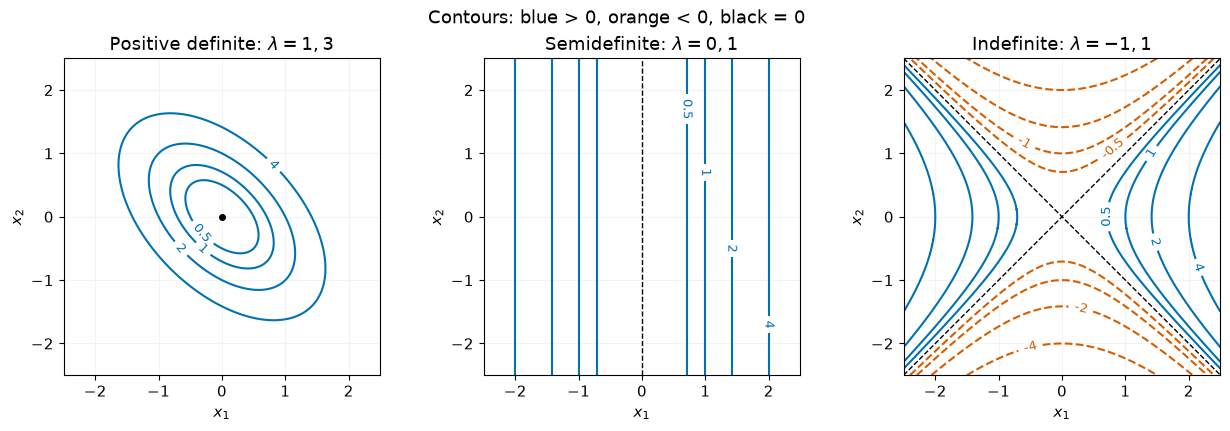

In [15]:
# 同一网格分别计算正定、半正定和不定二次型的函数值。
grid = np.linspace(-2.5, 2.5, 301)
x1, x2 = np.meshgrid(grid, grid)
surfaces = [2 * x1**2 + 2 * x1 * x2 + 2 * x2**2, x1**2, x1**2 - x2**2]
titles = [
    r"Positive definite: $\lambda=1,3$",
    r"Semidefinite: $\lambda=0,1$",
    r"Indefinite: $\lambda=-1,1$",
]

# 这些坐标只控制等高线数字放在哪里，不参与二次型或极值计算。
label_positions = [
    False,
    [(np.sqrt(0.5), 1.7), (1, 0.7), (np.sqrt(2), -0.5), (2, -1.7)],
    [(np.sqrt(0.5), 0), (np.sqrt(2), 1), (np.sqrt(2.16), -0.4), (np.sqrt(4.64), -0.8)],
]
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.2), layout="constrained")
# 先为三种二次型统一绘制正值轮廓；等比例坐标保留几何形状。
for ax, surface, title, positions in zip(axes, surfaces, titles, label_positions):
    positive = ax.contour(x1, x2, surface, levels=[0.5, 1, 2, 4], colors="#0072B2")
    ax.clabel(positive, fmt="%g", fontsize=9, manual=positions)
    ax.set(
        title=title,
        xlabel=r"$x_1$",
        ylabel=r"$x_2$",
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)

# 不定二次型还有负值区域，用橙色虚线与正值轮廓区分。
negative = axes[2].contour(
    x1,
    x2,
    surfaces[2],
    levels=[-4, -2, -1, -0.5],
    colors="#D55E00",
    linestyles="dashed",
)
axes[2].clabel(
    negative,
    fmt="%g",
    fontsize=9,
    manual=[
        (-0.5, -np.sqrt(4.25)),
        (0.3, -np.sqrt(2.09)),
        (-0.6, np.sqrt(1.36)),
        (0.8, np.sqrt(1.14)),
    ],
)
# 最后标出零值集合：原点、竖直线以及两条对角线。
axes[0].plot(0, 0, "o", color="black", markersize=4)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].plot(grid, grid, "k--", linewidth=1)
axes[2].plot(grid, -grid, "k--", linewidth=1)
fig.suptitle("Contours: blue > 0, orange < 0, black = 0", fontsize=13)
# 预期依次看到椭圆、平行直线、双曲线；不定情形的正负区域用蓝橙两色区分。
plt.show()

## 8 综合应用：检查平方惩罚有没有遗漏方向

设两个无单位参数组成 $x=(x_1,x_2)^T$。如果只惩罚两者的和，$(x_1+x_2)^2$ 无法区分 $(1,-1)^T$ 与零向量。为了同时限制差值，加入权重为 $\eta$ 的第二项；$\eta$ 是实数参数，正常的平方惩罚权重取非负值：

$$q_\eta(x)=(x_1+x_2)^2+\eta(x_1-x_2)^2
=x^T\begin{pmatrix}1+\eta&1-\eta\\1-\eta&1+\eta\end{pmatrix}x.$$

直接相乘可得，$(1,1)^T$ 对应特征值 2，$(1,-1)^T$ 对应特征值 $2\eta$。因此 $\eta>0$ 时正定，$\eta=0$ 时半正定但留有零方向，$\eta<0$ 时不定。沿 $x=(t,-t)^T$，$t$ 为任意实数，有 $q_\eta(x)=4\eta t^2$；负权重会让这个值随着 $|t|$ 增大而不断下降。

这个例子把“有没有漏掉方向”变成可核对的特征值问题。先检查矩阵对称性和特征关系，再比较同一条直线上的二次型，避免只在几个方便的点上判断。

In [16]:
v_sum = np.array([1.0, 1.0])
v_difference = np.array([1.0, -1.0])

for eta in [0.25, 0.0, -0.25]:
    penalty = np.array([[1 + eta, 1 - eta], [1 - eta, 1 + eta]])
    # eta=0.25、0、-0.25 时，特征值分别为 [0.5, 2]、[0, 2]、[-0.5, 2]。
    print(f"eta = {eta:g}，特征值：", np.linalg.eigh(penalty).eigenvalues)
    print("  和方向残差：", penalty @ v_sum - 2 * v_sum)  # 三种 eta 的残差均为 [0, 0]。
    print("  差方向残差：", penalty @ v_difference - 2 * eta * v_difference)  # 三种 eta 的残差均为 [0, 0]。
    print("  在 (1, -1) 上的值：", v_difference @ penalty @ v_difference)  # 按 eta 的给定顺序，二次型值为 1、0、-1。
# 值依次为 1、0、-1；改变权重会改变二次型的类别。

eta = 0.25，特征值： [0.5 2. ]
  和方向残差： [0. 0.]
  差方向残差： [0. 0.]
  在 (1, -1) 上的值： 1.0
eta = 0，特征值： [0. 2.]
  和方向残差： [0. 0.]
  差方向残差： [0. 0.]
  在 (1, -1) 上的值： 0.0
eta = -0.25，特征值： [-0.5  2. ]
  和方向残差： [0. 0.]
  差方向残差： [0. 0.]
  在 (1, -1) 上的值： -1.0


沿遗漏方向画剖面能直接看见权重变化的作用。它不是二维等高线，而是一维路径 $x=(t,-t)^T$ 上的函数值；横轴 $t$ 与纵轴 $q_\eta$ 都无单位。

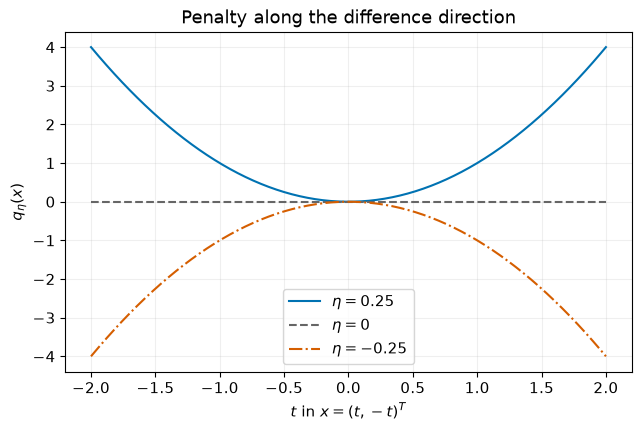

In [17]:
t = np.linspace(-2, 2, 201)
fig, ax = plt.subplots(figsize=(6.3, 4.2), layout="constrained")
for eta, color, style in [
    (0.25, "#0072B2", "-"),
    (0.0, "#666666", "--"),
    (-0.25, "#D55E00", "-."),
]:
    ax.plot(t, 4 * eta * t**2, color=color, linestyle=style, label=rf"$\eta={eta:g}$")
ax.set(
    xlabel=r"$t$ in $x=(t,-t)^T$",
    ylabel=r"$q_\eta(x)$",
    title="Penalty along the difference direction",
)
ax.grid(alpha=0.2)
ax.legend()
# 预期 eta>0 的抛物线向上、eta=0 为水平零线、eta<0 的抛物线向下。
plt.show()

## 本章小结

（1）行列式的绝对值描述面积或体积缩放，符号记录取向；零行列式表示线性变换丢失维度。

（2）特征关系是 $Av=\lambda v$，其中 $v\ne0$。对角化要求足够多的独立特征向量；实谱、重复根和可对角化不能混为一谈。

（3）实对称矩阵可用标准正交特征向量分解为 $Q\Lambda Q^T$。一般矩阵不能随意用转置代替逆，也不能随意交给 eigh。

（4）对称二次型在特征坐标下成为加权平方和。特征值符号决定正定、半正定或不定，零特征值对应可能遗漏的方向。

自查：能否从方程解释 J 为什么不能对角化？能否解释非对称矩阵的正特征值为什么不足以保证二次型为正？能否区分数值接近零和精确为零？

## 练习

（1）对 $A=\begin{pmatrix}4&1\\0&2\end{pmatrix}$ 手算特征值及对应向量，再用 eig 核对。构造 $P,D$，检查 $AP-PD$ 和 $PDP^{-1}-A$。说明两个特征向量是否正交，以及这是否妨碍对角化。残差的最大绝对值应小于 $10^{-12}$。

In [18]:
exercise_a = np.array([[4.0, 1.0], [0.0, 2.0]])
# 先写手算过程，再补充特征对、重构和正交性检查。

（2）令 $J_s=\begin{pmatrix}1&s\\0&1\end{pmatrix}$，其中 $s$ 为实数。比较 $s=0$ 与 $s=2$：特征值是否改变？特征空间维数是否改变？能否对角化？用 $(J_s-I)v=0$ 解释，不以 eig 返回的数组列数作为判据。

In [19]:
for s in [0.0, 2.0]:
    exercise_j = np.array([[1.0, s], [0.0, 1.0]])
    print("s =", s, "时 J_s - I：\n", exercise_j - np.eye(2))
# 根据方程约束写出每种情况下的特征空间基。

s = 0.0 时 J_s - I：
 [[0. 0.]
 [0. 0.]]
s = 2.0 时 J_s - I：
 [[0. 2.]
 [0. 0.]]


（3）把 $q(x)=3x_1^2-4x_1x_2+3x_2^2$ 写成对称矩阵形式，判断是否正定。画出 $q(x)=1$ 的等高线，并预测长轴方向。再把交叉项改为 $-6x_1x_2$，解释严格正定条件哪里发生变化，并给出一个非零的零值方向。

In [20]:
cross_coefficients = [-4.0, -6.0]
# 交叉项系数要分到两个对称位置；分别核对特征值并画图。

（4）对非对称矩阵 $M=\begin{pmatrix}2&6\\0&2\end{pmatrix}$，有人根据两个正特征值认定 $x^TMx>0$ 对所有非零 $x$ 成立。先写出对称部分，再找一个反例向量。说明应使用 eig 还是 eigh 分别分析 M 和它的对称部分，并用直接代入核对你的判断。

In [21]:
exercise_m = np.array([[2.0, 6.0], [0.0, 2.0]])
# 补充对称部分、选用的计算方法、反例向量及二次型值。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：重复特征值的次数与特征空间维数是不同的量。

提示 2：直接展开 $(J_s-I)v=0$，检查它对第二个分量的约束。

### 练习（2）参考解析

特征多项式始终是 $(1-\lambda)^2$，唯一特征值为 1，代数重数为 2。特征向量方程只有 $s v_2=0$。

当 $s=0$，任意二维向量都在特征空间内，基可取 $(1,0)^T,(0,1)^T$，矩阵已经是对角阵。当 $s=2$，必须 $v_2=0$，特征空间只有一维，无法选出两个线性无关特征向量，所以不能对角化。库返回两列数值向量不保证它们线性无关。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Georgia Tech：Interactive Linear Algebra | [§4.3 Determinants and Volumes](https://textbooks.math.gatech.edu/ila/determinants-volumes.html)，§4.3.1–4.3.3 的体积、相关性及线性变换；[§5.1 Eigenvalues and Eigenvectors](https://textbooks.math.gatech.edu/ila/eigenvectors.html)，定义与特征空间；[§5.2 The Characteristic Polynomial](https://textbooks.math.gatech.edu/ila/characteristic-polynomial.html)，特征方程；[§5.4 Diagonalization](https://textbooks.math.gatech.edu/ila/diagonalization.html)，对角化定理、重复特征值和矩阵幂；[§5.5 Complex Eigenvalues](https://textbooks.math.gatech.edu/ila/complex-eigenvalues.html)，实矩阵的复特征值。 |
| TU Delft：Linear algebra | [§5.1 Determinants as areas or volumes](https://interactivetextbooks.tudelft.nl/linear-algebra/Chapter5/DeterminantsGeometric.html)，§5.1.1–5.1.3 的二阶公式、有向面积和体积；[§8.1 Symmetric matrices](https://interactivetextbooks.tudelft.nl/linear-algebra/Chapter8/SymmetricMatrices.html)，Theorem 8.1.1 与 Propositions 8.1.1–8.1.3 的实谱、正交性、重数及正交对角化；[§8.2 Quadratic forms](https://interactivetextbooks.tudelft.nl/linear-algebra/Chapter8/QuadraticForms.html)，§8.2.1–8.2.3 的对称表示、主轴坐标和符号判别，§8.2.4 的等高线几何。 |
| Deep Learning 作者网站 | [第 2 章 Linear Algebra](https://www.deeplearningbook.org/contents/linear_algebra.html)，§2.6–2.7，印刷页 39–42：正交矩阵、实对称特征分解及正定、半正定条件。 |
| NumPy 官方文档 | NumPy 2.5：[linalg.det](https://numpy.org/doc/stable/reference/generated/numpy.linalg.det.html) 的行列式；[linalg.eig](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) 的返回顺序、列向量和复数情况；[linalg.eigh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html) 的适用条件、UPLO 与递增输出；[linalg.matrix_power](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_power.html) 的矩阵幂；[allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) 的绝对与相对容差含义。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.fill](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill.html) 的多边形填充；[Axes.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html) 的网格形状、显式等高线 levels 和线型。 |